### Notebook 4 : Polynomial Regression full dataset

##### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Load the Dataset

In [2]:
df = pd.read_csv('capstone.csv')

* Preview the dataset

In [3]:

print(df.head())

                       MemberName  EducationLevel  Attendance  TotalHours  \
0           Theekshana Rathnayake               3        79.9        43.7   
1  Mayura Sandakalum Sellapperuma               2        76.8        95.6   
2                 Amila Narangoda               3        96.6        75.9   
3                    Nisal Gamage               1        74.5        63.9   
4                Tharusha Vihanga               2        83.2        24.0   

   AssignmentsCompleted  HackathonParticipation  GitHubScore  PeerReviewScore  \
0                     2                       0         62.8              5.0   
1                     6                       0         87.4              2.7   
2                     8                       0         98.4              2.8   
3                     7                       0         76.8              1.7   
4                     6                       0         41.8              4.2   

                    CourseName  CapstoneScore  
0 

##### Data preparation

* Drop 'MemberName' (non-informative for prediction)

In [ ]:
df = df.drop(columns=['MemberName'])

* Convert 'CourseName' to numerical values using mapping

In [4]:
df['CourseName'] = df['CourseName'].map({
    'Foundations of ML': 0,
    'Production-Ready ML Systems': 1
})


* Separate Features and Target

In [5]:
feature_cols = ['EducationLevel', 'Attendance', 'TotalHours',
                'AssignmentsCompleted', 'HackathonParticipation',
                'GitHubScore', 'PeerReviewScore', 'CourseName']
target_col = 'CapstoneScore'

X = df[feature_cols].values
y = df[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (150, 8)
y shape: (150,)


*  Feature Scaling / Standardization

In [6]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

print("X_scaled shape:", X_scaled.shape)


X_scaled shape: (150, 8)


##### Generate Polynomial Features

* Create a function that generates polynomial features for any degree

In [7]:
def create_polynomial_features(X, degree):
    from itertools import combinations_with_replacement
    import numpy as np

    n_samples, n_features = X.shape
    features = [np.ones((n_samples, 1))]  # start with bias term

    for d in range(1, degree + 1):
        for indices in combinations_with_replacement(range(n_features), d):
            new_feature = np.prod(X[:, indices], axis=1).reshape(-1, 1)
            features.append(new_feature)

    return np.hstack(features)


In [8]:
X_poly_2 = create_polynomial_features(X_scaled, degree=2)
print("X_poly_2 shape:", X_poly_2.shape)


X_poly_2 shape: (150, 45)


##### Gradient Descent for Polynomial Regression (Degree 2)

In [ ]:
# Cost function (MSE)
def compute_cost(X, y, beta):
    m = len(y)
    predictions = X @ beta
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

# Gradient descent
def gradient_descent(X, y, learning_rate=0.1, num_iterations=1000):
    m, n = X.shape
    beta = np.zeros(n)
    cost_history = []

    for i in range(num_iterations):
        predictions = X @ beta
        errors = predictions - y
        gradients = (1 / m) * (X.T @ errors)
        beta -= learning_rate * gradients
        cost = compute_cost(X, y, beta)
        cost_history.append(cost)

        if i % 100 == 0 or i == num_iterations - 1:
            print(f"Iteration {i}: Cost={cost:.2f}")

    return beta, cost_history


* Run Gradient Descent

In [17]:
# Run gradient descent on polynomial features (degree 2)
beta_poly2, cost_history_poly2 = gradient_descent(X_poly_2, y, learning_rate=0.1, num_iterations=1000)

print("Final beta values (degree 2):")
print(beta_poly2)


Iteration 0: Cost=315.62
Iteration 100: Cost=32.39
Iteration 200: Cost=29.85
Iteration 300: Cost=29.74
Iteration 400: Cost=29.73
Iteration 500: Cost=29.73
Iteration 600: Cost=29.73
Iteration 700: Cost=29.73
Iteration 800: Cost=29.73
Iteration 900: Cost=29.73
Iteration 999: Cost=29.73
Final beta values (degree 2):
[20.79558786 -0.14377306  1.19908905  8.17130076 14.31001882 -4.30660958
 -0.03622203  2.69949562  9.50697916  0.3605089   0.75802857 -0.10891238
 -1.69361205  1.02817324  0.13137456 -0.92888385  0.11273557 -1.10268768
 -0.22766068  0.6719683  -2.05208375  0.50912933  1.65949609  0.8952794
  1.02328149 -0.03333982 -0.48266468  1.14689959  0.58915317 -7.59594844
 -1.22831566  0.13352354 -0.36853532 -0.9857878  13.71532887 19.87157282
  0.94258268  1.64972225 -0.37911665  0.56607675  1.26826412 -1.18842029
  0.08698119  0.49809383 20.03442035]


* Visualize Cost vs. Iteration

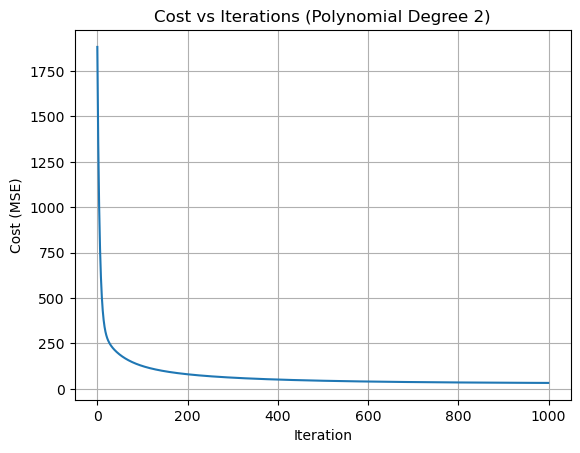

In [11]:
plt.plot(range(len(cost_history_poly2)), cost_history_poly2)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Iterations (Polynomial Degree 2)")
plt.grid(True)
plt.show()


* Learned Betas to Predict y

In [12]:
def predict(X, beta):
    return np.dot(X, beta)

y_pred_poly2 = predict(X_poly_2, beta_poly2)


* Calculate R2 score for degree 2 model

In [13]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


* Calculate and Print R2

In [14]:
r2_poly2 = r2_score(y, y_pred_poly2)
print(f"R² Score (Degree 2): {r2_poly2:.4f}")

R² Score (Degree 2): 0.8933


##### Gradient Descent for Polynomial Regression (Degree 2)

* Generate Degree 3 Data

In [18]:
X_poly_3 = create_polynomial_features(X_scaled, degree=3)
print("X_poly_3 shape:", X_poly_3.shape)

X_poly_3 shape: (150, 165)


Train using Gradient Descent (Degree 3)

In [19]:
beta_3, cost_history_3 = gradient_descent(X_poly_3, y, learning_rate=0.1, num_iterations=1000)
print("Final beta values (degree 3):")
print(beta_3)


Iteration 0: Cost=330.33
Iteration 100: Cost=14.13
Iteration 200: Cost=8.54
Iteration 300: Cost=6.29
Iteration 400: Cost=5.16
Iteration 500: Cost=4.50
Iteration 600: Cost=4.08
Iteration 700: Cost=3.78
Iteration 800: Cost=3.56
Iteration 900: Cost=3.39
Iteration 999: Cost=3.25
Final beta values (degree 3):
[ 2.05353450e+01 -5.86605826e-01  6.96378286e-01  2.49718613e+00
  8.47907212e+00 -3.50825787e+00  8.75078664e-01  1.69744372e+00
  3.24224033e+00  4.99326484e-01  1.68589855e+00  1.04701066e+00
 -7.61192280e-01  1.84448459e+00  1.73985382e-01 -7.29732300e-01
  1.17540484e+00  3.19873948e-01 -1.13725632e+00  1.71439183e+00
 -2.34449932e+00  8.83332163e-01  2.65291063e+00 -9.78342473e-01
 -2.63273492e+00 -6.55908708e-01 -9.94161452e-01  1.31850438e+00
 -8.79711420e-01 -8.44545229e+00  5.37754692e-01  9.67750734e-01
  9.70477361e-01 -1.62697248e+00  1.71642550e+01  1.97826222e+01
 -1.55846707e+00  3.33675744e+00 -2.38338156e+00  1.13554255e+00
  8.67821259e-01  2.02156428e+00 -9.15000873

* Evaluate R² Score

In [20]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# Predict
y_pred_3 = X_poly_3 @ beta_3
r2_3 = r2_score(y, y_pred_3)
print(f"R² Score (Degree 3): {r2_3:.4f}")


R² Score (Degree 3): 0.9893
